# ECG — Denoising & Long-Gap Inpainting (Images)
Este notebook treina e aplica um pipeline para **imagens de ECG** que:
1. Remove ruídos e grade;
2. **Detecta falhas longas** no traçado (gaps);
3. Reconstrói (inpainting) usando método clássico (OpenCV) **e** uma rede neural U-Net 2D.


In [1]:
# ==========================
# 0) Instalação de dependências
# ==========================
#!pip -q install opencv-python-headless scikit-image tensorflow matplotlib numpy tqdm pillow


In [2]:
# ==========================
# 1) Imports
# ==========================
import os, glob, math, random, io
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage import color, morphology, filters, exposure, util
import tensorflow as tf
from tensorflow.keras import layers, models

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


2025-08-18 13:00:17.663472: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def show(img, title=None, cmap='gray', size=(12,4)):
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title: plt.title(title)
    plt.axis('off')
    plt.show()


## Dados
- Se você tiver um diretório com **imagens de ECG** (`.png`, `.jpg`), preencha `DATA_DIR`.
- Se `DATA_DIR` for vazio ou não encontrado, o notebook **gera dados sintéticos**: traçado em grade colorida, com ruídos e falhas.


Total de imagens: 100


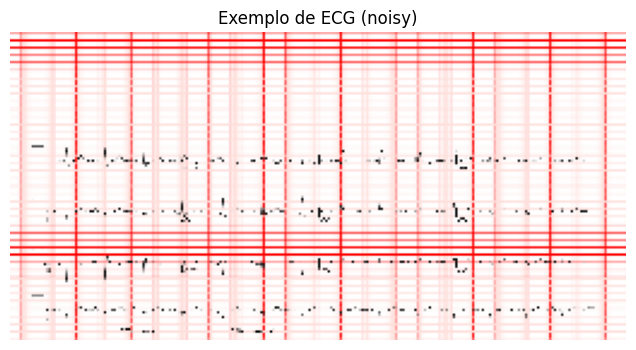

In [4]:
# ==========================
# 2) Carregar dados (ou gerar sintético)
# ==========================
DATA_DIR = 'ptbxlimage/records500/00000/' 
#DATA_DIR = ''
IMG_SIZE = (128, 256)  # (altura, largura)

def load_images_from_folder(folder, max_images=None):
    exts = ('*.png','*.jpg','*.jpeg','*.bmp','*.tif')
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
    if max_images:
        paths = paths[:max_images]
    imgs = []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))
        imgs.append(img)
    return imgs

def draw_ecg_like(height, width, color_trace=(60,60,180), grid_color=(230,140,140)):
    # Gera imagem sintética estilo ECG (fundo branco + grade + traçado)
    img = np.ones((height, width, 3), np.uint8) * 255
    step_small = 10
    step_big = 50
    for x in range(0, width, step_small):
        cv2.line(img, (x,0), (x,height), grid_color, 1 if x%step_big else 2)
    for y in range(0, height, step_small):
        cv2.line(img, (0,y), (width,y), grid_color, 1 if y%step_big else 2)
    t = np.linspace(0, 6*np.pi, width)
    base = height//2 + (np.sin(t*0.25)*height*0.05).astype(int)
    y = base + (np.sin(t)*height*0.07).astype(int)
    for i in range(width-1):
        cv2.line(img, (i, y[i]), (i+1, y[i+1]), color_trace, 2)
    return img

def add_noise_and_gaps(img, noise_std=10, long_gap_prob=0.3, min_gap=40, max_gap=160):
    noisy = img.copy().astype(np.float32)
    noisy += np.random.normal(0, noise_std, noisy.shape).astype(np.float32)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    h, w = noisy.shape[:2]
    if random.random() < long_gap_prob:
        gap_w = random.randint(min_gap, max_gap)
        x0 = random.randint(0, w-gap_w-1)
        noisy[:, x0:x0+gap_w, :] = 255
    for _ in range(5):
        gap_w = random.randint(5, 20)
        x0 = random.randint(0, w-gap_w-1)
        y0 = random.randint(0, h-1)
        noisy[max(0,y0-5):min(h,y0+5), x0:x0+gap_w, :] = 255
    return noisy

def generate_synthetic_dataset(n=200):
    imgs, gt = [], []
    for _ in tqdm(range(n), desc='Gerando sintético'):
        clean = draw_ecg_like(IMG_SIZE[0], IMG_SIZE[1])
        noisy = add_noise_and_gaps(clean, noise_std=12)
        imgs.append(noisy)
        gt.append(clean)
    return imgs, gt

if DATA_DIR and os.path.isdir(DATA_DIR):
    images = load_images_from_folder(DATA_DIR, max_images=100)
    gt_images = [im.copy() for im in images]
else:
    images, gt_images = generate_synthetic_dataset(100)

print(f'Total de imagens: {len(images)}')
show(images[0], 'Exemplo de ECG (noisy)')


## Pré-processamento
- **Atenuar grade** (HSV) e **extrair traçado** com top-hat + threshold adaptativo.


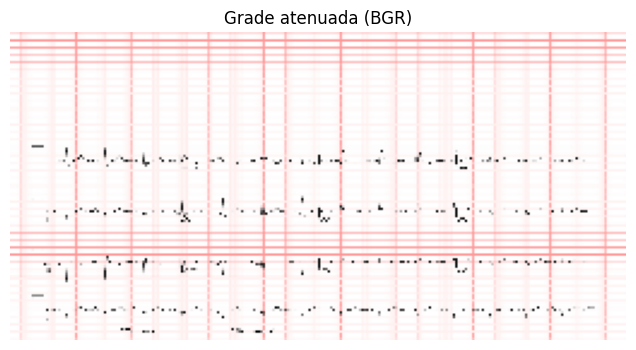

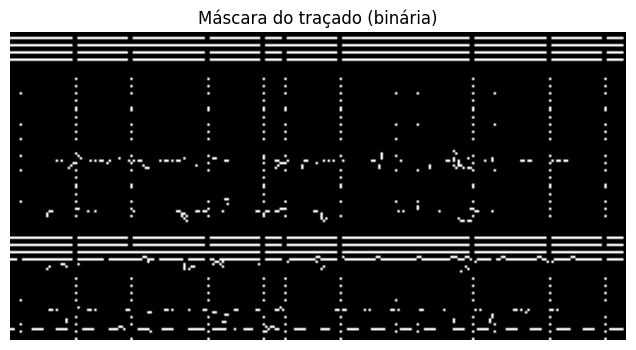

In [5]:
def suppress_grid(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    s *= 0.4
    hsv = cv2.merge([h, s, v])
    out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return out

def extract_trace_mask(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)
    th = cv2.adaptiveThreshold(tophat, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY, 33, -5)
    th = morphology.thin(th>0).astype(np.uint8)*255
    return th

demo = suppress_grid(images[0])
mask = extract_trace_mask(demo)
show(demo, 'Grade atenuada (BGR)')
show(mask, 'Máscara do traçado (binária)')


## Detecção de **falhas longas**
Heurística baseada em **colunas sem traçado** dentro do envelope do sinal.


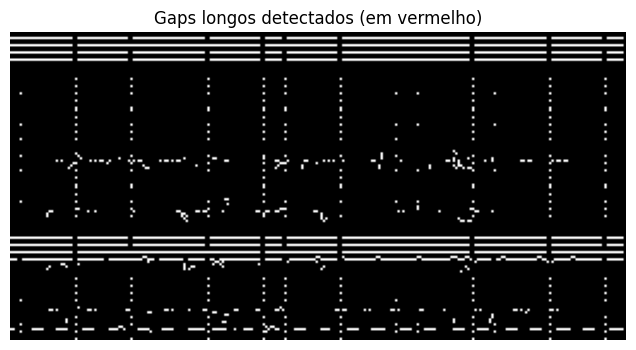

In [6]:
def detect_long_gaps(trace_mask, min_columns_gap=30):
    col_presence = (trace_mask>0).any(axis=0).astype(np.uint8)
    gaps = (col_presence==0).astype(np.uint8)
    idx = np.where(np.diff(np.concatenate(([0], gaps, [0]))))[0]
    runs = list(zip(idx[0::2], idx[1::2]))
    long_gaps = np.zeros_like(gaps, dtype=np.uint8)
    for s,e in runs:
        if (e - s) >= min_columns_gap:
            long_gaps[s:e] = 1
    gap_mask_2d = np.repeat(long_gaps[np.newaxis, :], trace_mask.shape[0], axis=0)*255
    return gap_mask_2d.astype(np.uint8), runs

gap_mask, runs = detect_long_gaps(mask, min_columns_gap=40)
overlay = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
overlay[gap_mask>0] = (0,0,255)
show(overlay, 'Gaps longos detectados (em vermelho)')


## Inpainting clássico (OpenCV — Telea)


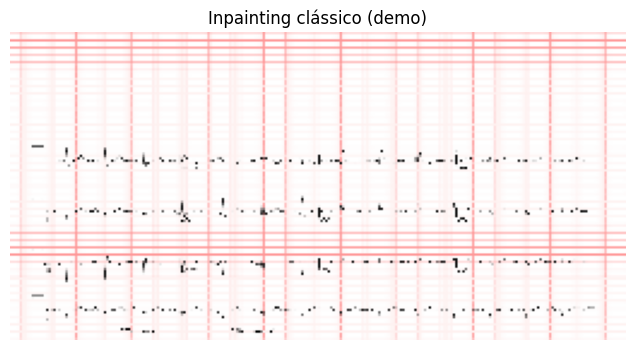

In [7]:
def classical_inpaint(img_bgr, gap_mask):
    inpainted = cv2.inpaint(img_bgr, (gap_mask>0).astype(np.uint8)*255, 3, cv2.INPAINT_TELEA)
    return inpainted

inpaint_demo = classical_inpaint(demo, gap_mask)
show(inpaint_demo, 'Inpainting clássico (demo)')


## Dataset para U-Net (mask-conditioned)
Entrada: **imagem ruidosa + máscara de falhas** (2 canais). Saída: **imagem limpa**.


In [8]:
def make_pair(img_bgr, gt_bgr=None):
    # Cria (input_img, input_mask, target_img). Se gt_bgr==None, usa self-supervision.
    if gt_bgr is None:
        gt_bgr = img_bgr.copy()
    noisy = add_noise_and_gaps(gt_bgr, noise_std=12, long_gap_prob=0.5, min_gap=30, max_gap=120)
    diff = cv2.absdiff(noisy, gt_bgr)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    mask = (gray > 25).astype(np.uint8)*255
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    noisy_f = noisy.astype(np.float32)/255.0
    gt_f = gt_bgr.astype(np.float32)/255.0
    mask_f = (mask>0).astype(np.float32)[..., None]
    gray_noisy = cv2.cvtColor((noisy_f*255).astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
    inp = np.concatenate([gray_noisy[..., None], mask_f], axis=-1)
    target = cv2.cvtColor((gt_f*255).astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
    return inp, target[..., None], noisy, gt_bgr, mask

X, Y = [], []
for img, gt in tqdm(zip(images, gt_images), total=len(images), desc='Preparando dataset'):
    img2 = suppress_grid(img)
    inp, target, noisy, gt_bgr, mask = make_pair(img2, gt)
    inp = cv2.resize(inp, (IMG_SIZE[1], IMG_SIZE[0]))
    target = cv2.resize(target, (IMG_SIZE[1], IMG_SIZE[0]))
    X.append(inp)
    Y.append(target)

X = np.stack(X, axis=0).astype(np.float32)
Y = np.stack(Y, axis=0).astype(np.float32)
print('Shapes:', X.shape, Y.shape)


Preparando dataset: 100%|██████████| 100/100 [00:00<00:00, 296.86it/s]

Shapes: (100, 128, 256, 2) (100, 128, 256)


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.15, random_state=42)
print(X_train.shape, X_val.shape)


(85, 128, 256, 2) (15, 128, 256, 2)


## Modelo U-Net 2D (condicionado à máscara)
Entrada `(H,W,2)` → Saída `(H,W,1)`


In [10]:
def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def unet(input_shape=(128,256,2)):
    inp = layers.Input(shape=input_shape)
    c1 = conv_block(inp, 32); p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);  p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 128); p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, 256); p4 = layers.MaxPooling2D()(c4)
    bn = conv_block(p4, 512)
    u4 = layers.UpSampling2D()(bn); u4 = layers.Concatenate()([u4, c4]); c5 = conv_block(u4, 256)
    u3 = layers.UpSampling2D()(c5); u3 = layers.Concatenate()([u3, c3]); c6 = conv_block(u3, 128)
    u2 = layers.UpSampling2D()(c6); u2 = layers.Concatenate()([u2, c2]); c7 = conv_block(u2, 64)
    u1 = layers.UpSampling2D()(c7); u1 = layers.Concatenate()([u1, c1]); c8 = conv_block(u1, 32)
    out = layers.Conv2D(1, 1, activation='sigmoid')(c8)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='mae')
    return model

model = unet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 2))
#model.summary()


In [11]:
EPOCHS = 10
BATCH = 2
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.2115 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - loss: 0.1281 - val_loss: 0.0864 - learning_rate: 0.0010
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - loss: 0.1027 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0898
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
43/43 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - loss: 0.0813 - val_loss: 0.1108 - learning_rate: 0.0010
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - loss: 0.0653 - val_loss: 0.0893 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## Avaliação e visualização
Mostramos: entrada, máscara, saída U-Net, alvo e inpainting clássico.


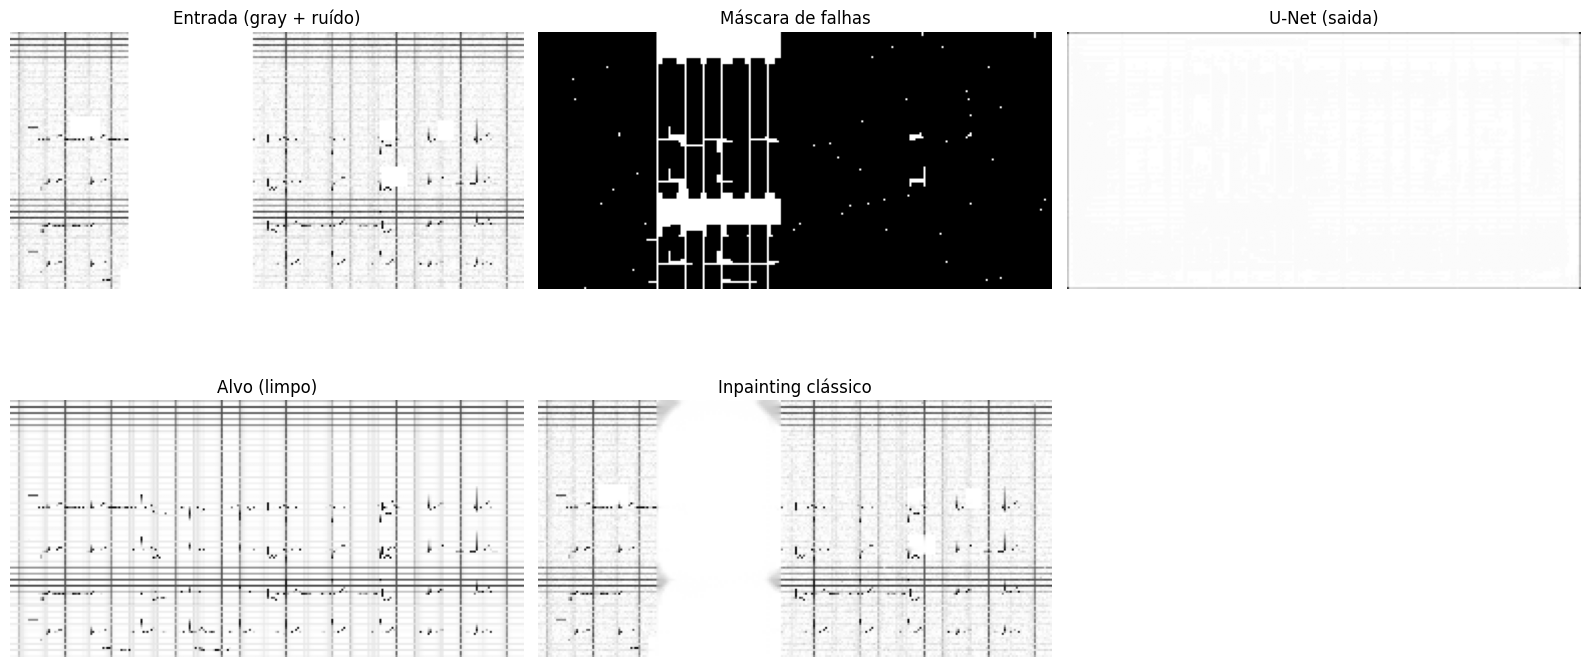

In [12]:
def classical_inpaint_gray(gray_img, mask):
    bgr = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    return classical_inpaint(bgr, mask)

def visualize_sample(idx=None):
    if idx is None:
        idx = np.random.randint(0, X_val.shape[0])
    inp = X_val[idx]
    target = Y_val[idx]
    pred = model.predict(inp[None,...], verbose=0)[0,:,:,0]
    img_in = (inp[:,:,0]*255).astype(np.uint8)
    msk_in = (inp[:,:,1]*255).astype(np.uint8)
    out = (pred*255).astype(np.uint8)
    if target.ndim == 3:
        tgt = (target[:,:,0]*255).astype(np.uint8)
    else:
        tgt = (target*255).astype(np.uint8)
    inpainted = classical_inpaint_gray(img_in, msk_in)
    plt.figure(figsize=(16,8))
    plt.subplot(2,3,1); plt.imshow(img_in, cmap='gray'); plt.title('Entrada (gray + ruído)'); plt.axis('off')
    plt.subplot(2,3,2); plt.imshow(msk_in, cmap='gray'); plt.title('Máscara de falhas'); plt.axis('off')
    plt.subplot(2,3,3); plt.imshow(out, cmap='gray'); plt.title('U-Net (saida)'); plt.axis('off')
    plt.subplot(2,3,4); plt.imshow(tgt, cmap='gray'); plt.title('Alvo (limpo)'); plt.axis('off')
    plt.subplot(2,3,5); plt.imshow(cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)); plt.title('Inpainting clássico'); plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_sample()


## Inferência em imagens reais + detecção de gaps longos


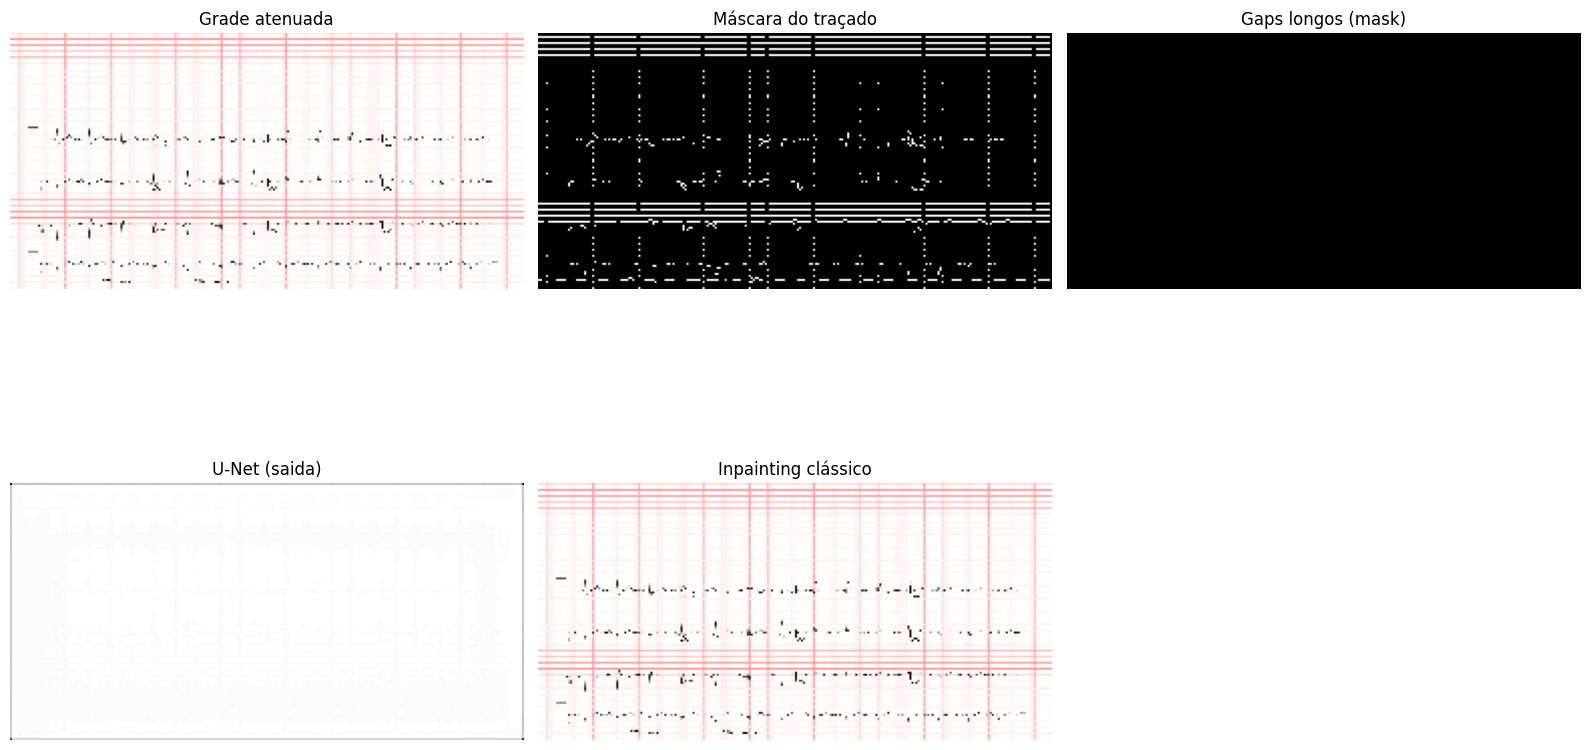

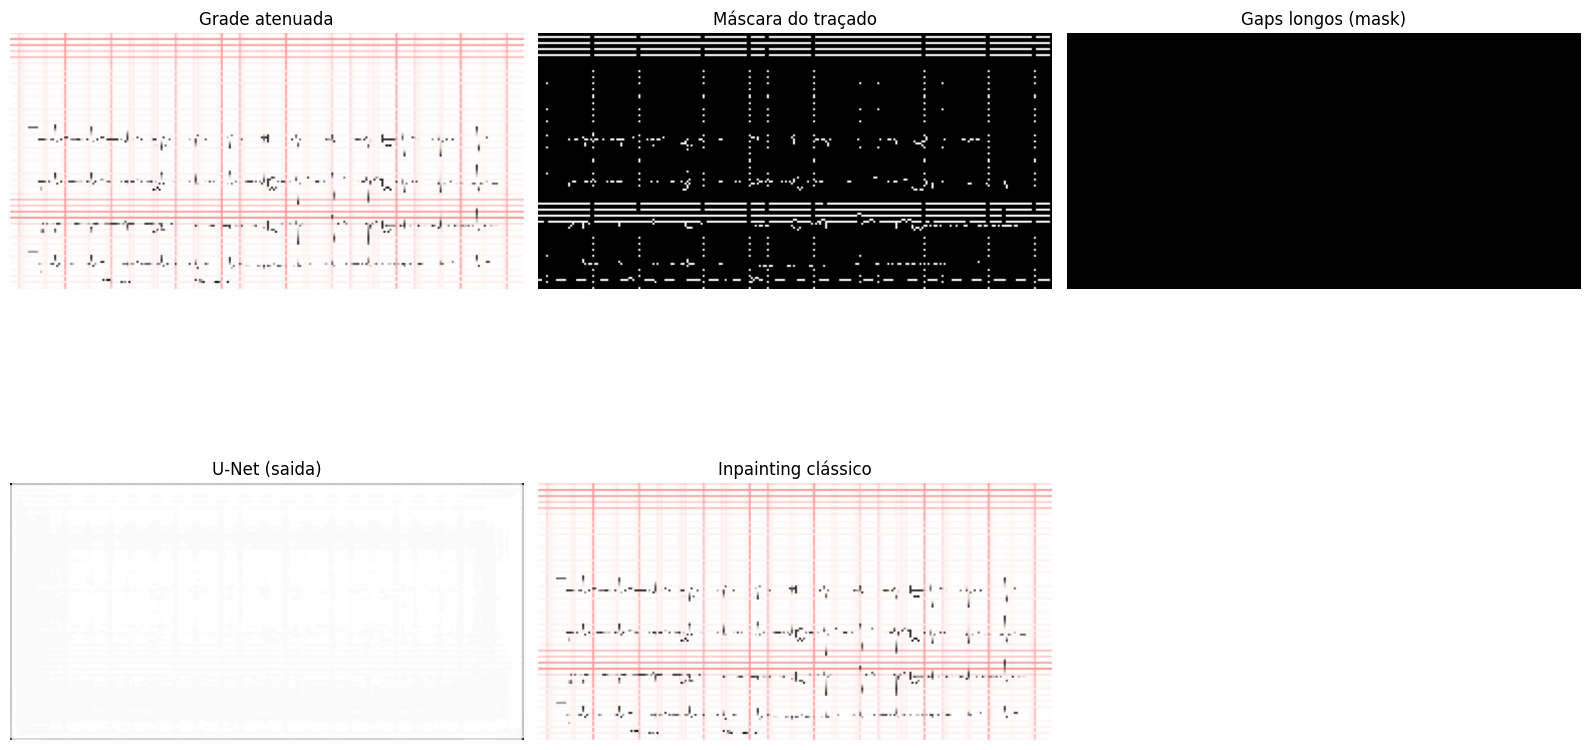

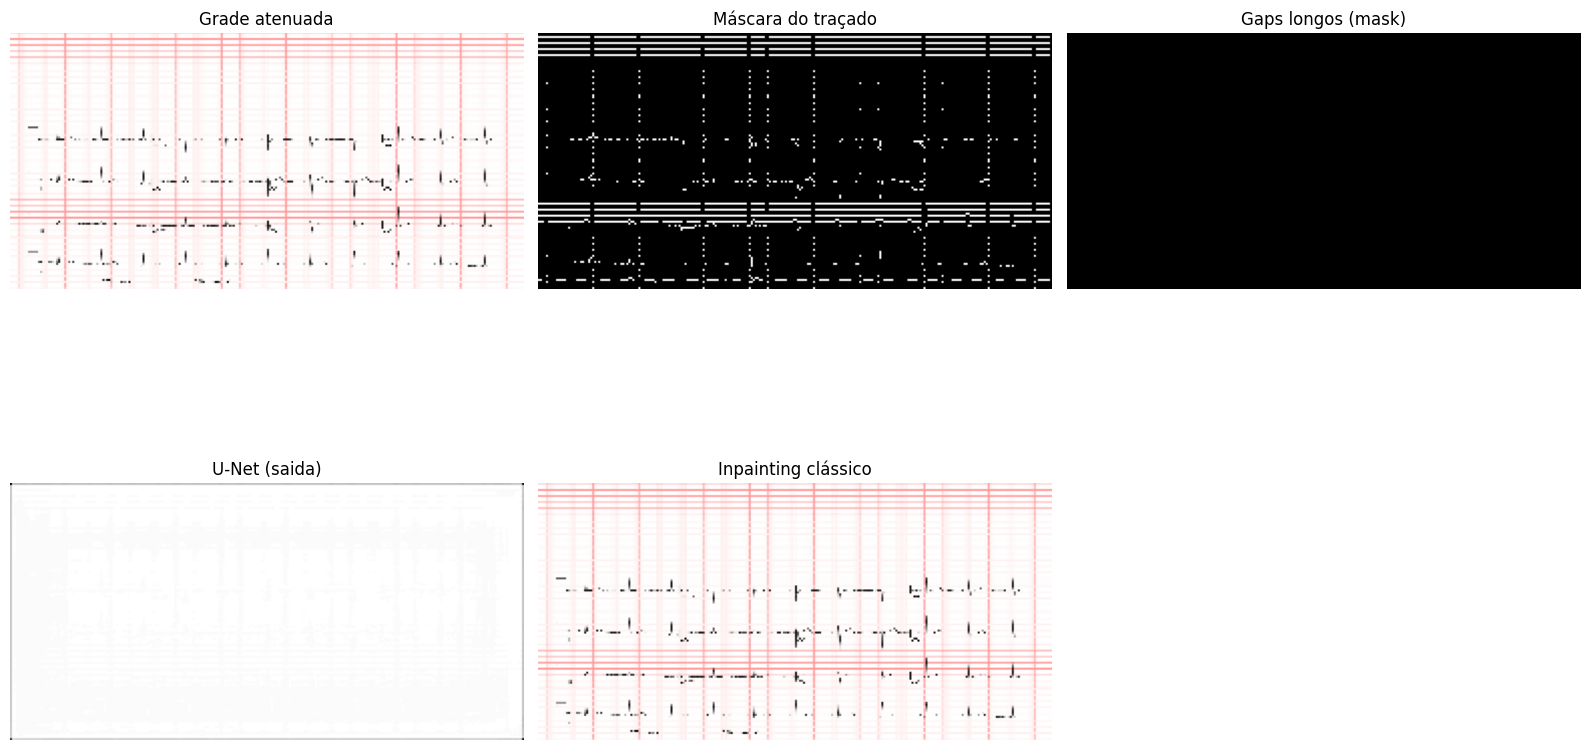

In [13]:
def run_full_inference(img_bgr):
    proc = suppress_grid(img_bgr)
    trace = extract_trace_mask(proc)
    gap_mask, _ = detect_long_gaps(trace, min_columns_gap=40)
    gray = cv2.cvtColor(proc, cv2.COLOR_BGR2GRAY).astype(np.float32)/255.0
    mask_f = (gap_mask>0).astype(np.float32)
    inp = np.stack([gray, mask_f], axis=-1)
    inp = cv2.resize(inp, (IMG_SIZE[1], IMG_SIZE[0]))
    out = model.predict(inp[None,...], verbose=0)[0,:,:,0]
    inpainted = classical_inpaint(cv2.resize(proc, (IMG_SIZE[1], IMG_SIZE[0])), (inp[:,:,1]*255).astype(np.uint8))
    return (proc, trace, gap_mask, (out*255).astype(np.uint8), inpainted)

for i in range(3):
    img = images[i]
    proc, trace, gap_mask, out, inpainted = run_full_inference(img)
    plt.figure(figsize=(16,10))
    plt.subplot(2,3,1); plt.imshow(cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)); plt.title('Grade atenuada'); plt.axis('off')
    plt.subplot(2,3,2); plt.imshow(trace, cmap='gray'); plt.title('Máscara do traçado'); plt.axis('off')
    plt.subplot(2,3,3); plt.imshow(gap_mask, cmap='gray'); plt.title('Gaps longos (mask)'); plt.axis('off')
    plt.subplot(2,3,4); plt.imshow(out, cmap='gray'); plt.title('U-Net (saida)'); plt.axis('off')
    plt.subplot(2,3,5); plt.imshow(cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)); plt.title('Inpainting clássico'); plt.axis('off')
    plt.tight_layout(); plt.show()


## Exportar modelo


In [14]:
os.makedirs('/mnt/data/models', exist_ok=True)
model_path = '/mnt/data/models/ecg_unet_mask.keras'
model.save(model_path)
print('Modelo salvo em:', model_path)


PermissionError: [Errno 13] Permission denied: '/mnt/data'

### Notas e ajustes rápidos
- Ajuste `min_columns_gap` conforme a resolução.
- A atenuação de grade por HSV pode ser calibrada.
- Aumente o dataset e varie máscaras para melhor inpainting.
- Experimente perdas como SSIM/Charbonnier para menos *blur*.
